# Detect Long-Term Air Quality Trends with Theil-Sen Analysis in Python

**Goal:** Detect and quantify long-term trends in air pollutant concentrations
using non-parametric statistical methods — the kind of analysis central to
academic research papers and regulatory trend reports.

**API keys required:** None (AURN is freely accessible)

**Aeolus features demonstrated:**
- `find_sites()` for site discovery
- `download()` for multi-year data retrieval
- `metrics.trend()` — Theil-Sen slope with Mann-Kendall significance test
- `metrics.trend()` with deseasonalisation (STL decomposition)
- `metrics.time_average()` for temporal aggregation
- `viz.plot_trend()` — trend visualisation with CI bands
- `viz.plot_time_variation()` — seasonal decomposition

**Statistical background:**
- **Theil-Sen estimator**: Robust regression that uses the median of all pairwise
  slopes. Resistant to outliers, unlike OLS.
- **Mann-Kendall test**: Non-parametric test for monotonic trend. Does not assume
  normality.
- **STL deseasonalisation**: Seasonal-Trend decomposition using LOESS, removing
  the annual cycle before fitting the trend.

In [1]:
import aeolus
from aeolus import metrics, viz
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

## 1. Select Sites

For robust trend detection we need at least 5 years of data.
We pick well-established AURN sites that have long records.

In [2]:
# Find AURN sites near London
sites = aeolus.find_sites(
    "AURN",
    near=(51.5074, -0.1278),
    radius_km=25,
)

# Pick a well-known long-running site
# MY1 = London Marylebone Road (major roadside, operational since 1997)
# KC1 = London N. Kensington (urban background, operational since 1996)
target_sites = ["MY1", "KC1"]

site_info = sites[sites["site_code"].isin(target_sites)]
site_info[["site_code", "site_name", "location_type", "distance_km"]]

,site_code,site_name,location_type,distance_km
70,MY1,London Marylebone Road,Urban Traffic,2.504474
71,MY1,London Marylebone Road,Urban Traffic,2.504474
72,MY1,London Marylebone Road,Urban Traffic,2.504474
73,MY1,London Marylebone Road,Urban Traffic,2.504474
74,MY1,London Marylebone Road,Urban Traffic,2.504474
...,...,...,...,...
184,KC1,London N. Kensington,Urban Background,6.116066
185,KC1,London N. Kensington,Urban Background,6.116066
186,KC1,London N. Kensington,Urban Background,6.116066
187,KC1,London N. Kensington,Urban Background,6.116066


## 2. Download Multi-Year Data

Download 5 years of hourly data. For publication-quality trends,
use 10+ years; we use 5 here for speed.

In [3]:
# Download 5 years
# Tip: extend to 10+ years for more robust trends
data = aeolus.download(
    "AURN",
    sites=target_sites,
    start_date=datetime(2019, 1, 1),
    end_date=datetime(2023, 12, 31),
)

print(f"Downloaded {len(data):,} rows")
print(f"Date range: {data['date_time'].min()} to {data['date_time'].max()}")
print(f"Sites: {data['site_code'].unique().tolist()}")
print(f"Pollutants: {data['measurand'].unique().tolist()}")

/Users/ruaraidhdobson/Dropbox/Personal/sls/aeolus/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded 3,241,274 rows
Date range: 2019-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Sites: ['MY1', 'KC1']
Pollutants: ['O3', 'NO', 'NO2', 'NOXasNO2', 'SO2', 'CO', 'PM10', 'PM2.5', 'ETHANE', 'ETHENE', 'ETHYNE', 'PROPANE', 'PROPENE', 'iBUTANE', 'nBUTANE', '1BUTENE', 't2BUTENE', 'c2BUTENE', 'iPENTANE', 'nPENTANE', '13BDIENE', 't2PENTEN', '1PENTEN', '2MEPENT', 'ISOPRENE', 'nHEXANE', 'nHEPTANE', 'iOCTANE', 'nOCTANE', 'BENZENE', 'TOLUENE', 'ETHBENZ', 'mpXYLENE', 'oXYLENE', '123TMB', '124TMB', '135TMB']


## 3. Single-Site Trend Analysis

Run `metrics.trend()` on a single site. The default settings use monthly
aggregation with STL deseasonalisation — the standard approach in the
air quality literature.

In [4]:
# Trend for NO2 at Marylebone Road
my1_data = data[data["site_code"] == "MY1"]

result = metrics.trend(my1_data, pollutant="NO2")

print(f"NO\u2082 trend at {result.site_code} ({result.first_year}\u2013{result.last_year})")
print(f"  Slope: {result.slope:+.2f} \u00b5g/m\u00b3/year")
print(f"  Change: {result.slope_pct:+.1f}%/year relative to mean")
print(f"  95% CI: [{result.ci_lower:+.2f}, {result.ci_upper:+.2f}] \u00b5g/m\u00b3/year")
print(f"  p-value: {result.p_value:.4f} ({'significant' if result.p_value < 0.05 else 'not significant'})")
print(f"  Deseasonalised: {result.deseasonalised}")
print(f"  Data points: {result.n_points}")

NO₂ trend at MY1 (2019–2023)
  Slope: -3.52 µg/m³/year
  Change: -7.5%/year relative to mean
  95% CI: [-5.25, -1.73] µg/m³/year
  p-value: 0.0000 (significant)
  Deseasonalised: True
  Data points: 58


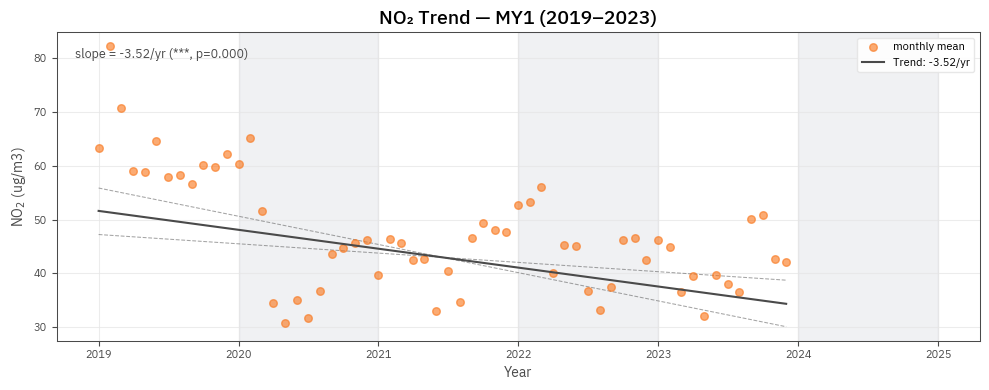

In [5]:
# Visualise the trend
fig = viz.plot_trend(
    my1_data,
    result,
    title=f"NO\u2082 Trend \u2014 {result.site_code} ({result.first_year}\u2013{result.last_year})",
)
plt.show()

## 4. Multi-Site Comparison

When the input data contains multiple sites, `trend()` returns a list
of `TrendResult` objects — one per site. This makes it easy to compare
trends across a roadside and background pair.

In [6]:
# Multi-site trend
results = metrics.trend(data, pollutant="NO2")

# Ensure it's always a list for consistent iteration
if not isinstance(results, list):
    results = [results]

print(f"{'Site':<6} {'Type':<12} {'Slope':>10} {'%/yr':>8} {'p-value':>10} {'Sig?':>6}")
print("-" * 55)
for r in results:
    site_meta = sites[sites["site_code"] == r.site_code]
    stype = site_meta["location_type"].iloc[0] if not site_meta.empty else "Unknown"
    sig = "*" if r.p_value < 0.05 else ""
    print(f"{r.site_code:<6} {stype:<12} {r.slope:>+8.2f} {r.slope_pct:>+7.1f}% {r.p_value:>10.4f} {sig:>5}")

Site   Type              Slope     %/yr    p-value   Sig?
-------------------------------------------------------
MY1    Urban Traffic    -3.52    -7.5%     0.0000     *
KC1    Urban Background    -1.80    -8.5%     0.0000     *


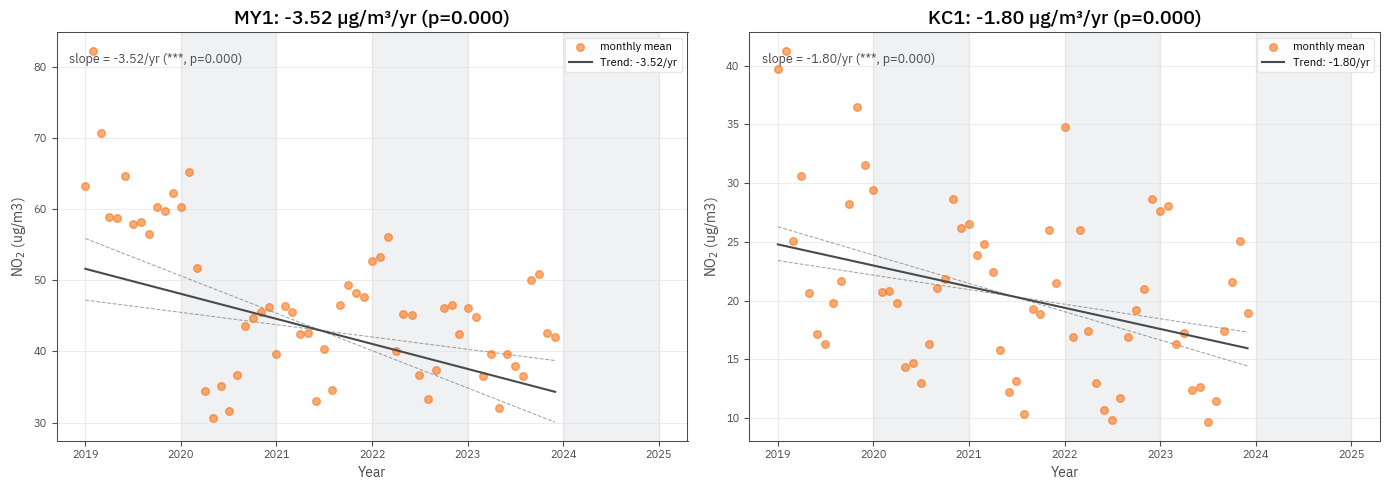

In [7]:
# Side-by-side trend plots
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    site_data = data[data["site_code"] == r.site_code]
    viz.plot_trend(
        site_data, r,
        title=f"{r.site_code}: {r.slope:+.2f} \u00b5g/m\u00b3/yr (p={r.p_value:.3f})",
        ax=ax,
    )

plt.tight_layout()
plt.show()

## 5. Effect of Deseasonalisation

Compare the trend with and without removing the seasonal cycle.
For pollutants with strong seasonality (O\u2083, PM\u2082.\u2085), deseasonalisation
can reveal the underlying trend that seasonal variation obscures.

In [8]:
# With vs without deseasonalisation
trend_deseasoned = metrics.trend(my1_data, pollutant="NO2", deseason=True)
trend_raw = metrics.trend(my1_data, pollutant="NO2", deseason=False)

print(f"{'Method':<20} {'Slope':>10} {'CI lower':>10} {'CI upper':>10} {'p-value':>10}")
print("-" * 62)
print(f"{'Deseasonalised':<20} {trend_deseasoned.slope:>+8.2f} {trend_deseasoned.ci_lower:>+10.2f} "
      f"{trend_deseasoned.ci_upper:>+10.2f} {trend_deseasoned.p_value:>10.4f}")
print(f"{'Raw (seasonal)':<20} {trend_raw.slope:>+8.2f} {trend_raw.ci_lower:>+10.2f} "
      f"{trend_raw.ci_upper:>+10.2f} {trend_raw.p_value:>10.4f}")

Method                    Slope   CI lower   CI upper    p-value
--------------------------------------------------------------
Deseasonalised          -3.52      -5.25      -1.73     0.0000
Raw (seasonal)          -3.88      -5.60      -1.99     0.0003


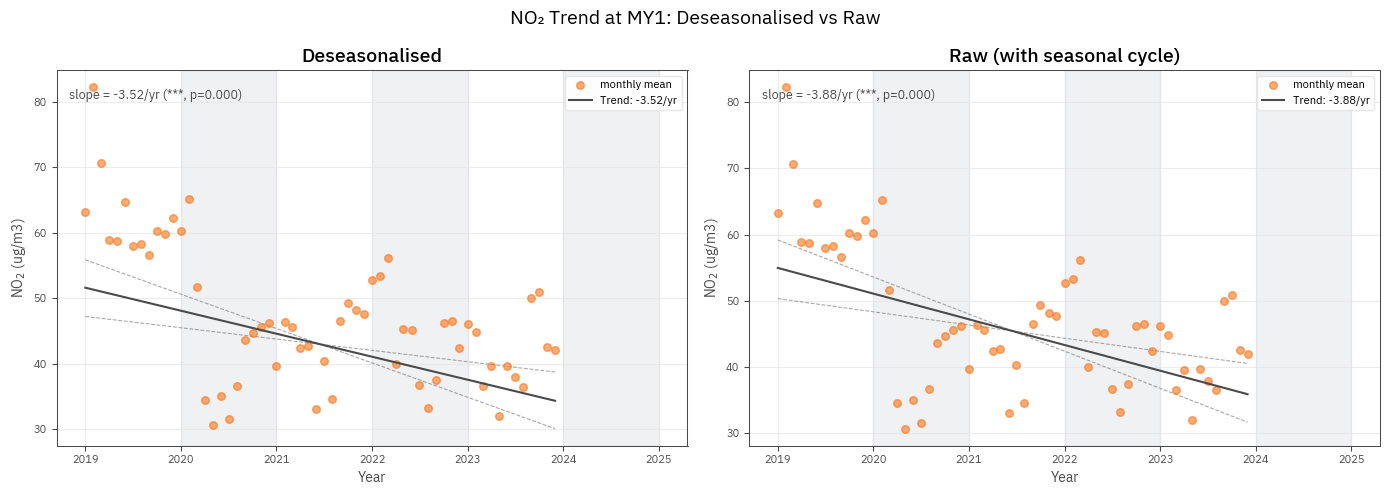

In [9]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz.plot_trend(my1_data, trend_deseasoned, title="Deseasonalised", ax=axes[0])
viz.plot_trend(my1_data, trend_raw, title="Raw (with seasonal cycle)", ax=axes[1])

fig.suptitle(f"NO\u2082 Trend at {trend_deseasoned.site_code}: Deseasonalised vs Raw", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Different Aggregation Periods

The `avg_time` parameter controls the temporal resolution before fitting.
Monthly gives the most data points; annual is the smoothest.

In [10]:
print(f"{'Period':<10} {'Slope':>10} {'%/yr':>8} {'p-value':>10} {'Points':>8}")
print("-" * 48)

for avg_time in ["month", "season", "year"]:
    try:
        r = metrics.trend(my1_data, pollutant="NO2", avg_time=avg_time)
        print(f"{avg_time:<10} {r.slope:>+8.2f} {r.slope_pct:>+7.1f}% {r.p_value:>10.4f} {r.n_points:>7}")
    except ValueError as e:
        print(f"{avg_time:<10} Insufficient data: {e}")

Period          Slope     %/yr    p-value   Points
------------------------------------------------
month         -3.52    -7.5%     0.0000      58
season        -3.73    -8.0%     0.0490      19


year       Insufficient data: Insufficient data for trend analysis at site MY1: 5 points (need >= 6) after year aggregation.


## 7. Multi-Pollutant Trends

Run trend analysis across all available pollutants at a site to build
a comprehensive picture of air quality change.

In [11]:
# Analyse all pollutants at KC1 (urban background)
kc1_data = data[data["site_code"] == "KC1"]
available = kc1_data["measurand"].unique()

print(f"Available pollutants at KC1: {available.tolist()}")
print()

trend_results = {}
print(f"{'Pollutant':<10} {'Slope':>12} {'%/yr':>8} {'p-value':>10} {'Sig?':>6}")
print("-" * 48)

for poll in available:
    try:
        r = metrics.trend(kc1_data, pollutant=poll)
        trend_results[poll] = r
        sig = "*" if r.p_value < 0.05 else ""
        print(f"{poll:<10} {r.slope:>+10.2f} {r.slope_pct:>+7.1f}% {r.p_value:>10.4f} {sig:>5}")
    except ValueError as e:
        print(f"{poll:<10} Skipped: insufficient data")

Available pollutants at KC1: ['O3', 'NO', 'NO2', 'NOXasNO2', 'SO2', 'CO', 'PM10', 'PM2.5', 'ETHANE', 'ETHENE', 'ETHYNE', 'PROPANE', 'PROPENE', 'iBUTANE', 'nBUTANE', '1BUTENE', 't2BUTENE', 'c2BUTENE', 'iPENTANE', 'nPENTANE', '13BDIENE', 't2PENTEN', '1PENTEN', '2MEPENT', 'ISOPRENE', 'nHEXANE', 'nHEPTANE', 'iOCTANE', 'nOCTANE', 'BENZENE', 'TOLUENE', 'ETHBENZ', 'mpXYLENE', 'oXYLENE', '123TMB', '124TMB', '135TMB']

Pollutant         Slope     %/yr    p-value   Sig?
------------------------------------------------
O3              +2.63    +5.1%     0.0009     *
NO              -0.89   -17.0%     0.0000     *
NO2             -1.80    -8.5%     0.0000     *


NOXasNO2        -3.41   -11.7%     0.0000     *
SO2             -0.26   -20.2%     0.0005     *
CO              +0.01    +7.2%     0.0000     *
PM10            -0.45    -3.3%     0.0032     *
PM2.5           -0.21    -2.5%     0.0439     *


ETHANE     Skipped: insufficient data
ETHENE     Skipped: insufficient data
ETHYNE     Skipped: insufficient data
PROPANE    Skipped: insufficient data
PROPENE    Skipped: insufficient data
iBUTANE    Skipped: insufficient data


nBUTANE    Skipped: insufficient data
1BUTENE    Skipped: insufficient data
t2BUTENE   Skipped: insufficient data
c2BUTENE   Skipped: insufficient data
iPENTANE   Skipped: insufficient data


nPENTANE   Skipped: insufficient data
13BDIENE   Skipped: insufficient data
t2PENTEN   Skipped: insufficient data
1PENTEN    Skipped: insufficient data
2MEPENT    Skipped: insufficient data
ISOPRENE   Skipped: insufficient data
nHEXANE    Skipped: insufficient data


nHEPTANE   Skipped: insufficient data
iOCTANE    Skipped: insufficient data
nOCTANE    Skipped: insufficient data
BENZENE    Skipped: insufficient data


TOLUENE    Skipped: insufficient data
ETHBENZ    Skipped: insufficient data
mpXYLENE   Skipped: insufficient data
oXYLENE    Skipped: insufficient data
123TMB     Skipped: insufficient data
124TMB     Skipped: insufficient data


135TMB     Skipped: insufficient data


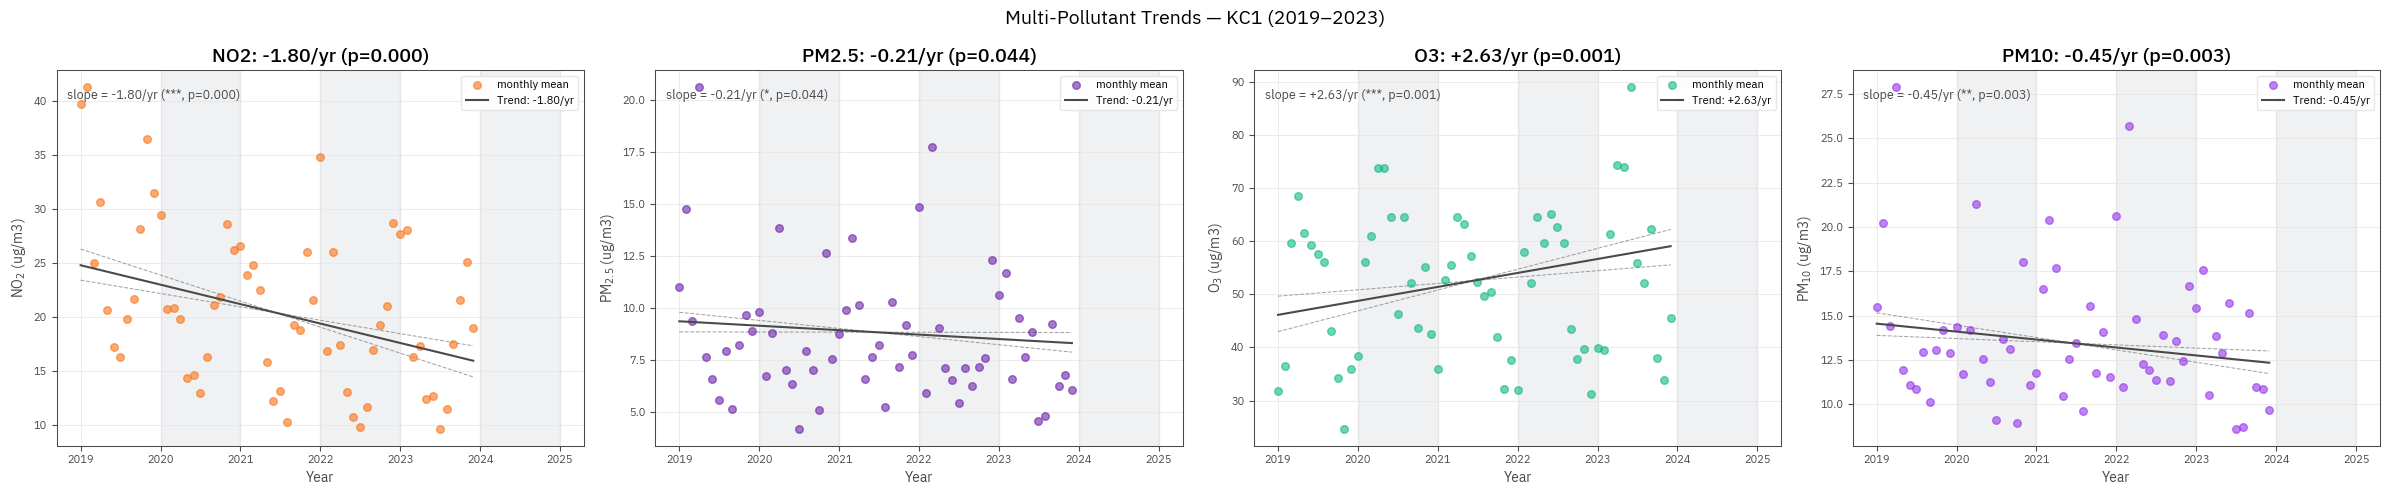

In [12]:
# Plot trends for the key pollutants
key_pollutants = [p for p in ["NO2", "PM2.5", "O3", "PM10"] if p in trend_results]
n = len(key_pollutants)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, poll in zip(axes, key_pollutants):
        r = trend_results[poll]
        viz.plot_trend(
            kc1_data, r,
            title=f"{poll}: {r.slope:+.2f}/yr (p={r.p_value:.3f})",
            ax=ax,
        )

    fig.suptitle(f"Multi-Pollutant Trends \u2014 KC1 ({r.first_year}\u2013{r.last_year})", fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Seasonal Context

Use `plot_time_variation()` alongside the trend to understand both
the long-term trajectory and the seasonal cycle.

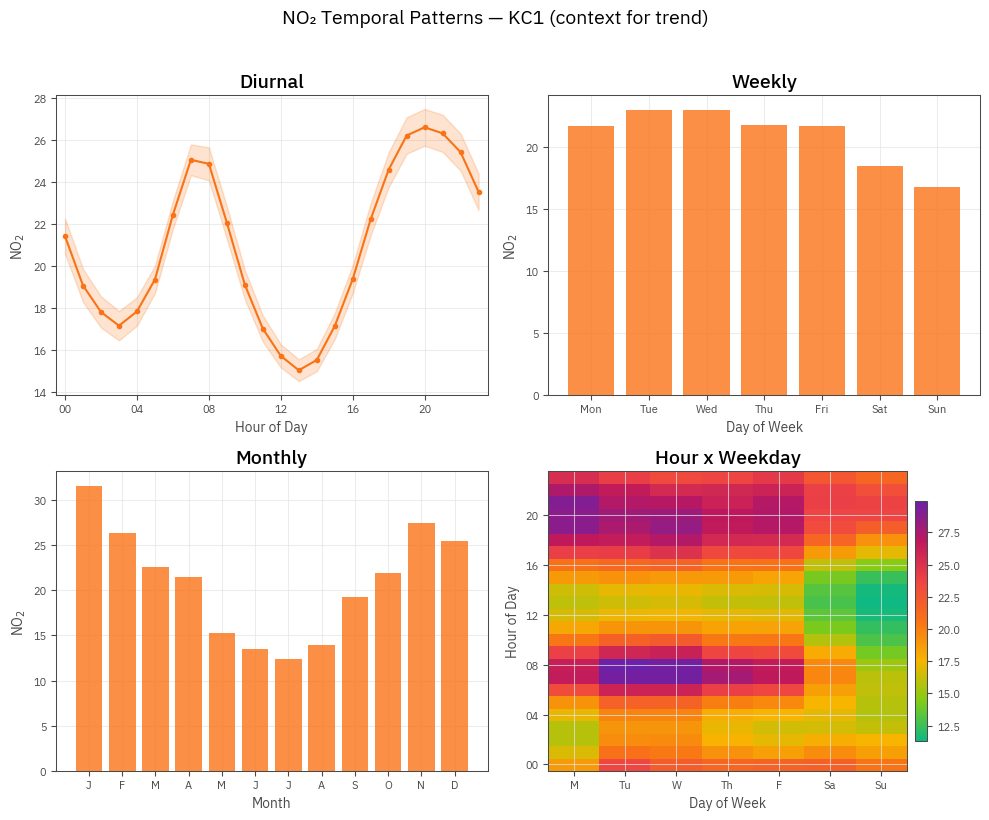

In [13]:
# Time variation shows the seasonal patterns that trend() deseasonalises
fig = viz.plot_time_variation(
    kc1_data,
    pollutant="NO2",
    title="NO\u2082 Temporal Patterns \u2014 KC1 (context for trend)",
)
plt.show()

## Summary

This notebook demonstrated:

1. **Theil-Sen trend estimation** — robust, non-parametric, outlier-resistant
2. **Mann-Kendall significance** — p-values without normality assumptions
3. **STL deseasonalisation** — removing the annual cycle to isolate the trend
4. **Multi-site comparison** — roadside vs background trend differences
5. **Multi-pollutant analysis** — comprehensive trend picture at a single site
6. **Aggregation sensitivity** — monthly vs seasonal vs annual resolution

### Interpreting results
- **Negative slopes** indicate improving air quality (concentrations declining)
- **p < 0.05** indicates a statistically significant trend
- **slope_pct** gives the rate of change relative to the mean — useful for
  comparing pollutants with different concentration ranges
- **Deseasonalisation** is important for NO₂ (winter peaks) and O₃ (summer peaks)

### Extending this analysis
- Use 10–20 years for publication-quality trends
- Set `autocor=True` for autocorrelation-corrected significance tests
- Compare trends across UK cities using Notebook 04's multi-network framework
- Export results to a DataFrame for inclusion in reports:

```python
import pandas as pd
trend_df = pd.DataFrame([vars(r) for r in results])
trend_df.to_csv("trends.csv", index=False)
```